Paquetes necesarios

In [1]:
import cv2  
import numpy as np
import matplotlib.pyplot as plt

Inicializaciones

In [2]:
#Dimensiones de la imagen a crear
ancho = 800
alto = 800

**TAREA**: Sin herramientas de IA, crea una imagen, p.e. de 800x800 píxeles, con la textura del tablero de ajedrez.
Una vez resuelto de forma manual, resuelve la misma tarea usando un asistente de IA de tu elección (Claude, ChatGPT, Copilot, etc.). Compara ambas versiones en el informe de la práctica.

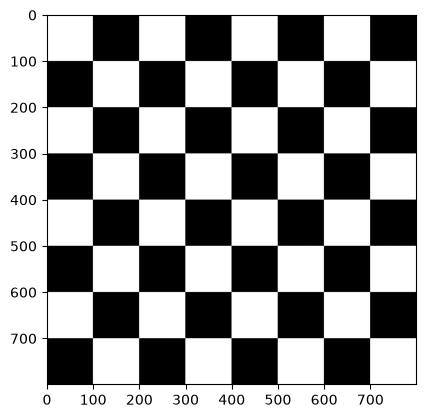

In [3]:
# Creamos una imagen base para el tablero (de un solo plano)
tablero_img = np.zeros((alto, ancho, 1), dtype=np.uint8) 

# tablero 8x8 por lo que cada casilla mide 100x100 pixeles
for i in range(8):
    for j in range(8):
        if (i + j) % 2 == 0:
            
            x_inicial = j * 100
            x_final = (j+1) * 100

            y_inicial = i*100
            y_final = (i+1)*100

            tablero_img[y_inicial:y_final, x_inicial:x_final] = 255 

plt.imshow(tablero_img, cmap='gray')
plt.show()

Solución con IA

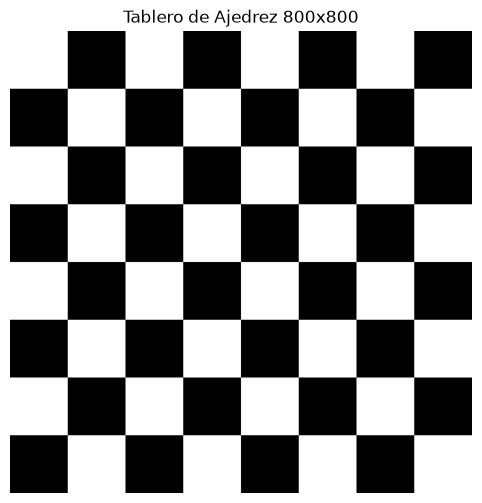

In [4]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# 1. Definir dimensiones
tamano_imagen = 800
num_casillas = 8
tamano_casilla = tamano_imagen // num_casillas

# 2. Crear un lienzo negro de 800x800 (matriz de ceros en escala de grises)
tablero = np.zeros((tamano_imagen, tamano_imagen), dtype=np.uint8)

# 3. Pintar las casillas blancas alternadas usando slicing de matrices
for i in range(num_casillas):
    for j in range(num_casillas):
        # Si la suma de las coordenadas de la cuadrícula es par, la pintamos de blanco (255)
        if (i + j) % 2 == 0:
            y_inicio = i * tamano_casilla
            y_fin = (i + 1) * tamano_casilla
            x_inicio = j * tamano_casilla
            x_fin = (j + 1) * tamano_casilla
            
            # Asignar el valor blanco a ese bloque de píxeles
            tablero[y_inicio:y_fin, x_inicio:x_fin] = 255

# 4. Mostrar la imagen directamente en el Notebook
plt.figure(figsize=(6, 6))
# Usamos cmap='gray' porque es una imagen de un solo canal (escala de grises)
plt.imshow(tablero, cmap='gray')
plt.title("Tablero de Ajedrez 800x800")
plt.axis('off') # Oculta los ejes numéricos para un resultado más limpio
plt.show()

**TAREA**: Crear una imagen estilo Mondrian (un ejemplo https://www3.gobiernodecanarias.org/medusa/ecoescuela/sa/2017/04/17/descubriendo-a-mondrian/) con las funciones de dibujo de OpenCV.
No hagas uso de herramientas de IA, parte del ejemplo anterior.

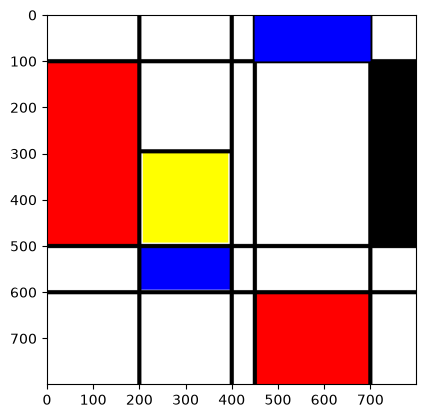

In [5]:
color_img = np.zeros((alto,ancho,3), dtype = np.uint8)

#Modifica todos los planos a color blanco (todas las filas y columnas)
color_img[:,:,:] = 255

#Lineas negras verticales
cv2.line(color_img,(200,0),(200, alto),(0,0,0),8)
cv2.line(color_img,(400,0),(400, alto),(0,0,0),8)
cv2.line(color_img,(450,0),(450, alto),(0,0,0),8)
cv2.line(color_img,(700,0),(700, alto),(0,0,0),8)
cv2.line(color_img,(200,295),(400, 295),(0,0,0),8)


#Lineas negras horizontales
cv2.line(color_img,(0,600),(ancho, 600),(0,0,0),8)
cv2.line(color_img,(0,500),(ancho, 500),(0,0,0),8)
cv2.line(color_img,(0,100),(ancho, 100),(0,0,0),8)

#formas rectangulares
cv2.rectangle(color_img,(0,105),(195, 495),(255,0,0),-1)
cv2.rectangle(color_img,(450,0),(700, 100),(0,0,255),-1)
cv2.rectangle(color_img,(205,505),(395, 594),(0,0,255),-1)
cv2.rectangle(color_img,(208,300),(392, 492),(255,255,0),-1)
cv2.rectangle(color_img,(455,605),(695, alto),(255,0,0),-1)
cv2.rectangle(color_img,(700,100),(ancho, 500),(0,0,0),-1)


plt.imshow(color_img) 
plt.show()


**TAREA**:
Pintar círculos en las posiciones del píxel más claro y oscuro de cada fotograma captado por la cámara. ¿Funciona de forma fluida o a saltos? En el segundo caso, ¿podrías acelerarlo?
Si haces uso de herramientas de IA, incluye la conversación.


In [6]:
vid = cv2.VideoCapture(0)   # para abrir la camara

while(True):      
    # fotograma a fotograma
    ret, frame = vid.read()
  
    # Hay nuevo fotograma
    if ret:  

        # Convertimos fotograma a blanco y negro
        frame_gris = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

        # buscamos pixel mas claro y el mas oscuro
        minVal, maxVal, minLoc, maxLoc = cv2.minMaxLoc(frame_gris)

        # dibujamos los circulos en esos pixeles
        cv2.circle(frame, minLoc, 20, (255, 0, 0), 3)
        cv2.circle(frame, maxLoc, 20, (0, 0, 255), 3)

        # Muestra fotograma
        cv2.imshow('Vid', frame)

    
    # Detenemos pulsando ESC
    if cv2.waitKey(20) == 27:
        break
  
# Libera el objeto de captura
vid.release()
# Destruye ventanas
cv2.destroyAllWindows()

cv2.waitKey(1)      # para solucionar el problema de las ventanas de mac

-1

TAREA: Llevar a cabo una propuesta propia de pop art.
Incluye fuentes consultadas. 
Si haces uso de herramientas de IA, incluye la conversación.

In [7]:
vid = cv2.VideoCapture(0)

#Dimensiones de la cámara
w = int(vid.get(cv2.CAP_PROP_FRAME_WIDTH))
h = int(vid.get(cv2.CAP_PROP_FRAME_HEIGHT))

#Fuerzo a mitad de resolución para ocupar menos pantalla
w=int(w/2)
h=int(h/2)

#Descomentar para otro sistema operativo
#vid.set(cv2.CAP_PROP_FRAME_WIDTH, w) #En Mac no reacciona a estos comandos
#vid.set(cv2.CAP_PROP_FRAME_HEIGHT, h)

#Imagen conjunta 3x original
collage = np.zeros((h*3,w*3,3), dtype = np.uint8)

#Fila 1
p1 = collage[0:h, 0:w]       # Arriba izquierda
p2 = collage[0:h, w:w*2]     # Arriba Centro
p3 = collage[0:h, w*2:w*3]   # Arriba Derecha

# Fila 2
p4 = collage[h:h*2, 0:w]     # Medio Izquierda
p5 = collage[h:h*2, w:w*2]   # Medio Centro 
p6 = collage[h:h*2, w*2:w*3] # Medio Derecha

# Fila 3
p7 = collage[h*2:h*3, 0:w]     # Abajo Izquierda
p8 = collage[h*2:h*3, w:w*2]   # Abajo Centro
p9 = collage[h*2:h*3, w*2:w*3] # Abajo Derecha

while True:      
    # fotograma a fotograma
    ret, frameIN = vid.read()

    #Menor tamaño
    frame = cv2.resize(frameIN, (int(w),int(h)),cv2.INTER_NEAREST)

    if ret:

        #Aplanamos la imagen para quitar degradados 
        gris = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

        # si el pixel tiene mas de 100 de luz, *255 sino 0
        gris_plano = (gris > 100) * 255

        #Pintamos las pantallas
            # miramos donde los pixeles valen 255 y 0, y pintamos con el color que deseemos en esas coordenadas
        p1[gris_plano == 255] = [19, 247, 224]  
        p1[gris_plano == 0] = [247, 19, 217]

        p2[gris_plano == 255] = [255, 255, 0]
        p2[gris_plano == 0] = [255, 0, 0]

        p3[gris_plano == 255] = [0, 255, 255]
        p3[gris_plano == 0] = [0, 0, 255]

        p4[gris_plano == 255] = [255, 0, 255]
        p4[gris_plano == 0] = [0, 255, 0]

        p5[gris_plano == 255] = [255, 255, 255]
        p5[gris_plano == 0] = [0, 0, 0]

        p6[gris_plano == 255] = [200, 200, 200]
        p6[gris_plano == 0] = [0, 50, 200]

        p7[gris_plano == 255] = [150, 255, 50]
        p7[gris_plano == 0] = [50, 0, 100]

        p8[gris_plano == 255] = [255, 150, 150]
        p8[gris_plano == 0] = [100, 50, 0]

        p9[gris_plano == 255] = [0, 150, 255]
        p9[gris_plano == 0] = [50, 0, 0]
    
        # Muestra composición
        cv2.imshow('Cam', collage)
    
    # Detenemos pulsado ESC
    if cv2.waitKey(20) == 27:
        break
  
# Libera el objeto de captura
vid.release()
# Destruye ventanas
cv2.destroyAllWindows()
cv2.waitKey(1)

-1